# Heat Exposure Analysis
## Workshop Notebook — Hazard Series (5 of 6)

This notebook loads and processes heat data from the climate atlas of Serbia about the seven hottest days of the year for air and pavement temperature. To account for climate change in the medium future, 2 degree Celsius and urban heat islands are added. Finally, the heat data is applied to the national road network of Serbia.

## Imports and Settings

In [154]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm
import rasterio
import pandas as pd
import geopandas as gpd
from pathlib import Path
import contextily as cx
from scipy.ndimage import zoom
from rasterstats import zonal_stats
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.mask import mask as rio_mask
import pyproj
from rasterio.transform import from_bounds
from rasterio.features import geometry_mask
from shapely.geometry import mapping
from rasterio.warp import calculate_default_transform
from rasterio.transform import from_bounds as transform_from_bounds
from rasterio.io import MemoryFile
from rasterio.transform import rowcol

### Paths and output settings

In [155]:
BASE_DIR = Path(r"C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2")

data_path = BASE_DIR / "input_files"
temperature_path = data_path / "Temperatures climate change"
figure_path = BASE_DIR / "figures"
intermediate_results_path = BASE_DIR / "intermediate_results"
arcgis_results = BASE_DIR / "results" / "ArcGIS layers"
arcgis_gpkg = arcgis_results / "Geopackages"

# Input rasters
HISTORIC_AIR_TEMP_TIF   = temperature_path / "TX7D_1961-1990.tif"
CURRENT_AIR_TEMP_TIF    = temperature_path / "TX7D_1991-2020.tif"
CURRENT_PAV_TEMP_TIF    = temperature_path / "TPAV_2021-2025.tif"
SMOD_TIF                = data_path / "GHS_SMOD_E2025_GLOBE_R2023A_54009_1000_V2_0_R4_C20.tif"

# Roads
ROADS_PATH = data_path / "DeoniceRSDP-Jul2025..shp"

OUTPUT_FOLDER = figure_path
DPI = 300

for d in [figure_path, intermediate_results_path, arcgis_results, arcgis_gpkg]:
    d.mkdir(parents=True, exist_ok=True)

### Bins and colour configuration

In [156]:
# Air temperature bins and colours (24-35 deg C range)
ABS_BINS   = [24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
ABS_COLORS = [
    "#2166ac", "#4393c3", "#92c5de", "#d1e5f0", "#fddbc7",
    "#f4a582", "#d6604d", "#b2182b", "#800026", "#4d0010",
]

# Difference bins and colours (current - historic)
DIFF_BINS   = [-2.5, -1.5, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5]
DIFF_COLORS = [
    "#2166ac", "#92c5de", "#d1e5f0", "#fddbc7",
    "#f4a582", "#d6604d", "#b2182b", "#67000d",
]

# Pavement temperature bins and colours (50-64 deg C range)
ABS_BINS_PAV   = [50, 53, 56, 59, 62, 64]
ABS_COLORS_PAV = [
    "#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026",
]

## Helper Functions

In [157]:
def read_tif(path):
    """Open a GeoTIFF; return (data_2d, bounds, crs) with nodata -> NaN."""
    with rasterio.open(path) as src:
        data   = src.read(1).astype(float)
        nodata = src.nodata
        bounds = src.bounds
        crs    = src.crs
    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)
    return data, bounds, crs


def resample_to_match(data_src, data_ref):
    """Bilinear-resample data_src to the same shape as data_ref."""
    zoom_r = data_ref.shape[0] / data_src.shape[0]
    zoom_c = data_ref.shape[1] / data_src.shape[1]
    nan_mask       = np.isnan(data_src).astype(float)
    resampled      = zoom(np.nan_to_num(data_src, nan=0.0), (zoom_r, zoom_c), order=1)
    resampled_mask = zoom(nan_mask, (zoom_r, zoom_c), order=1) > 0.5
    resampled[resampled_mask] = np.nan
    return resampled


def _reproject_bounds_to_3857(bounds, crs):
    """Convert raster bounds from native CRS to Web Mercator (EPSG:3857)."""
    transformer = pyproj.Transformer.from_crs(crs, "EPSG:3857", always_xy=True)
    left,  bottom = transformer.transform(bounds.left,  bounds.bottom)
    right, top    = transformer.transform(bounds.right, bounds.top)
    return left, bottom, right, top


def _apply_panel_style(ax, title, serbia_3857):
    """White-background panel with Serbia outline and OSM basemap."""
    serbia_3857.plot(ax=ax, facecolor="none", edgecolor="#333333",
                     linewidth=1.5, zorder=4)
    cx.add_basemap(ax=ax, source=cx.providers.OpenStreetMap.Mapnik,
                   alpha=0.35, attribution=False, zoom="auto")
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10, color="#222222")


def mask_to_serbia(data, bounds, crs, serbia_gdf):
    """Return a copy of data with all pixels outside Serbia set to NaN."""
    serbia_proj = serbia_gdf.to_crs(crs)
    rows, cols  = data.shape
    transform   = from_bounds(
        bounds.left, bounds.bottom, bounds.right, bounds.top, cols, rows
    )
    outside = geometry_mask(
        [mapping(geom) for geom in serbia_proj.geometry],
        out_shape=(rows, cols),
        transform=transform,
        invert=False,
    )
    masked = data.copy()
    masked[outside] = np.nan
    return masked


def save_lyrx_layer(gdf, gpkg_path, lyrx_path, layer_name, labels, colors, width_mapping, field, title=None):
    """Save GeoDataFrame to GeoPackage + ArcGIS Pro .lyrx."""
    import json as _json

    gdf.to_file(gpkg_path, driver="GPKG", layer=layer_name)
    print(f"Saved GeoPackage -> {gpkg_path}")

    try:
        import arcpy
    except ImportError:
        print("arcpy not available -- .lyrx skipped.")
        return

    title = title or layer_name
    gpkg_layer_path = str(gpkg_path.absolute()) + f"/{layer_name}"
    tmp_layer_name = f"tmp_lyr_{layer_name}"
    arcpy.management.MakeFeatureLayer(gpkg_layer_path, tmp_layer_name)
    tmp_lyrx = lyrx_path.with_suffix(".tmp.lyrx")
    arcpy.management.SaveToLayerFile(tmp_layer_name, str(tmp_lyrx), "ABSOLUTE")
    arcpy.management.Delete(tmp_layer_name)

    with open(tmp_lyrx) as f:
        lyrx = _json.load(f)

    def _make_symbol(hex_color, width):
        h = hex_color.lstrip("#")
        r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
        return {
            "type": "CIMSymbolReference",
            "symbol": {
                "type": "CIMLineSymbol",
                "symbolLayers": [{
                    "type": "CIMSolidStroke", "enable": True,
                    "capStyle": "Round", "joinStyle": "Round",
                    "width": width,
                    "color": {"type": "CIMRGBColor", "values": [r, g, b, 100]},
                }],
            },
        }

    renderer = {
        "type": "CIMUniqueValueRenderer",
        "defaultLabel": "<all other values>",
        "defaultSymbolPatch": "Default",
        "defaultSymbol": _make_symbol("#cccccc", 0.5),
        "defaultSymbolVisible": False,
        "fields": [field],
        "groups": [{
            "type": "CIMUniqueValueGroup",
            "classes": [
                {
                    "type": "CIMUniqueValueClass",
                    "label": label, "patch": "Default",
                    "symbol": _make_symbol(color, width_mapping.get(label, 1.0)),
                    "values": [{"type": "CIMUniqueValue", "fieldValues": [label]}],
                    "visible": True,
                }
                for label, color in zip(labels, colors)
            ],
            "heading": field,
        }],
        "useDefaultSymbol": False,
    }

    lyrx["layerDefinitions"][0]["renderer"] = renderer
    lyrx["layerDefinitions"][0]["name"] = title

    with open(lyrx_path, "w") as f:
        _json.dump(lyrx, f, indent=2)

    tmp_lyrx.unlink()
    print(f"Saved layer file -> {lyrx_path}")

## Load Serbia outline

In [158]:
world = gpd.read_file(data_path / "ne_10m_admin_0_countries.shp")
country_plot = world.loc[world.SOV_A3 == 'SRB']
serbia_3857 = country_plot.to_crs(3857)
print(f"Loaded Serbia: {len(serbia_3857)} polygon(s)")

Loaded Serbia: 1 polygon(s)


## 1. Historic vs Current Air Temperature

In [159]:
hist_data, hist_bounds, hist_crs = read_tif(HISTORIC_AIR_TEMP_TIF)
curr_data, curr_bounds, curr_crs = read_tif(CURRENT_AIR_TEMP_TIF)

hist_stem = HISTORIC_AIR_TEMP_TIF.stem
curr_stem = CURRENT_AIR_TEMP_TIF.stem

# Resample if grids differ
if hist_data.shape != curr_data.shape:
    print(f"  Resampling historic {hist_data.shape} -> current {curr_data.shape}")
    hist_data = resample_to_match(hist_data, curr_data)

diff_data = curr_data - hist_data

# Statistics: Serbia pixels only
diff_serbia = mask_to_serbia(diff_data, curr_bounds, curr_crs, serbia_3857)
valid = diff_serbia[~np.isnan(diff_serbia)]

if len(valid) > 0:
    print(f"Difference statistics (within Serbia)")
    print(f"  Min:    {valid.min():.4f} deg C")
    print(f"  Max:    {valid.max():.4f} deg C")
    print(f"  Mean:   {valid.mean():.4f} deg C")
    print(f"  Median: {np.median(valid):.4f} deg C")

Difference statistics (within Serbia)
  Min:    0.9425 deg C
  Max:    2.4907 deg C
  Mean:   1.8558 deg C
  Median: 1.8692 deg C


## 2. Current Pavement Temperature

In [164]:
data, bounds, crs = read_tif(CURRENT_PAV_TEMP_TIF)

# Mask to Serbia only
data_serbia = mask_to_serbia(data, bounds, crs, serbia_3857)
valid = data_serbia[~np.isnan(data_serbia)]

print(f"Min  : {valid.min():.2f} deg C")
print(f"Max  : {valid.max():.2f} deg C")
print(f"\nQuintile breaks (5 equal portions):")
for p, v in zip([0, 20, 40, 60, 80, 100], np.percentile(valid, [0, 20, 40, 60, 80, 100])):
    print(f"  {p:>3}th percentile: {v:.2f} deg C")

Min  : 46.97 deg C
Max  : 56.95 deg C

Quintile breaks (5 equal portions):
    0th percentile: 46.97 deg C
   20th percentile: 52.41 deg C
   40th percentile: 54.07 deg C
   60th percentile: 54.72 deg C
   80th percentile: 55.05 deg C
  100th percentile: 56.95 deg C


### Pavement temperature + 2 deg C climate change

In [178]:
data_future = data + 2

## 3. Urban Heat Island Effect

Reproject the SMOD urbanisation raster, apply +2 deg C climate change and +5 deg C for urban areas.

In [170]:
# Reproject SMOD to EPSG:4326
with rasterio.open(SMOD_TIF) as smod_src:
    dst_transform, dst_width, dst_height = calculate_default_transform(
        smod_src.crs, "EPSG:4326",
        smod_src.width, smod_src.height, *smod_src.bounds,
        dst_width=1000, dst_height=1000,
    )

    smod_reprojected = np.empty((dst_height, dst_width), dtype=np.float32)

    reproject(
        source=rasterio.band(smod_src, 1),
        destination=smod_reprojected,
        src_transform=smod_src.transform,
        src_crs=smod_src.crs,
        dst_transform=dst_transform,
        dst_crs="EPSG:4326",
        resampling=Resampling.nearest,
        src_nodata=smod_src.nodata,
        dst_nodata=np.nan,
    )

smod_reprojected = smod_reprojected.astype(float)

# Clip SMOD to pavement raster extent
row_min, col_min = rowcol(dst_transform, bounds.left, bounds.top, op=int)
row_max, col_max = rowcol(dst_transform, bounds.right, bounds.bottom, op=int)

row_min = max(0, row_min)
col_min = max(0, col_min)
row_max = min(dst_height, row_max)
col_max = min(dst_width, col_max)

smod_clipped = smod_reprojected[row_min:row_max, col_min:col_max]
print("SMOD clipped shape:", smod_clipped.shape)
print("Unique SMOD classes:", np.unique(smod_clipped[~np.isnan(smod_clipped)]))

# Reproject pavement temperature onto the clipped SMOD grid
smod_clip_transform = transform_from_bounds(
    bounds.left, bounds.bottom, bounds.right, bounds.top,
    smod_clipped.shape[1], smod_clipped.shape[0]
)

data_reprojected = np.empty(smod_clipped.shape, dtype=np.float32)

with rasterio.open(CURRENT_PAV_TEMP_TIF) as climate_src:
    reproject(
        source=rasterio.band(climate_src, 1),
        destination=data_reprojected,
        dst_crs="EPSG:4326",
        dst_transform=smod_clip_transform,
        src_transform=climate_src.transform,
        src_crs=climate_src.crs,
        src_nodata=climate_src.nodata,
        dst_nodata=np.nan,
        resampling=Resampling.nearest,
    )
    
data_reprojected = data_reprojected.astype(float)
data_reprojected = np.where(
    (data_reprojected <= 0) | (data_reprojected > 100),
    np.nan,
    data_reprojected
)
# Apply +2 deg C climate change
data_future_fine = data_reprojected + 2

# Apply urban heat island offsets
UHI_OFFSETS = {30: 5.0, 23: 5.0, 22: 5.0}

data_uhi = data_future_fine.copy()
for smod_class, offset in UHI_OFFSETS.items():
    mask = smod_clipped == smod_class
    data_uhi[mask] = data_uhi[mask] + offset
    print(f"  Class {smod_class}: {mask.sum():>8,} cells  (+{offset} deg C)")

print(f"\nOutput shape : {data_uhi.shape}")
print(f"Min          : {np.nanmin(data_uhi):.2f} deg C")
print(f"Max          : {np.nanmax(data_uhi):.2f} deg C")

# Save raster
out_tif = intermediate_results_path / "future_pavement_temperatures.tif"
with rasterio.open(
    out_tif, "w", driver="GTiff",
    height=data_uhi.shape[0], width=data_uhi.shape[1],
    count=1, dtype="float32", crs="EPSG:4326",
    transform=smod_clip_transform, nodata=np.nan, compress="deflate",
) as dst:
    dst.write(data_uhi.astype("float32"), 1)
print(f"Saved: {out_tif}")

SMOD clipped shape: (462, 300)
Unique SMOD classes: [10. 11. 12. 13. 21. 22. 23. 30.]
  Class 30:      724 cells  (+5.0 deg C)
  Class 23:      515 cells  (+5.0 deg C)
  Class 22:      200 cells  (+5.0 deg C)

Output shape : (462, 300)
Min          : 43.51 deg C
Max          : 64.81 deg C
Saved: C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2\intermediate_results\future_pavement_temperatures.tif


Bin distribution for: Pavement Temperature with urban heat islands under climate change
  Bin                Cells  % of total
  -------------------------------------
  < 50                 261        0.4%
  50 - 53            6,429       10.0%
  53 - 56           17,945       28.0%
  56 - 59           38,570       60.2%
  59 - 62              476        0.7%
  62 - 64              365        0.6%
  > 64                   0        0.0%
  -------------------------------------
  Total             64,046      100.0%



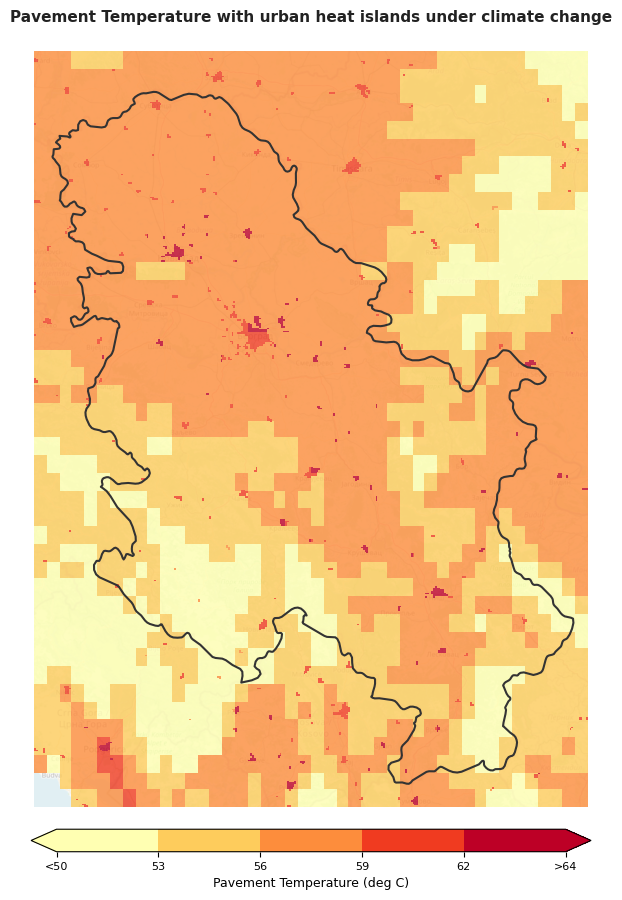

In [171]:
plot_single(data_uhi, "Pavement Temperature with urban heat islands under climate change",
           serbia_3857, bounds=bounds, crs=crs)

## 4. Assign temperatures to roads

In [172]:
roads = gpd.read_file(ROADS_PATH)
roads = gpd.clip(roads, country_plot.to_crs(roads.crs))
roads = roads.to_crs(crs)
print(f"Road segments: {len(roads):,}")

Road segments: 1,828


### Current pavement temperatures on roads

In [173]:
def assign_road_temperatures(roads, raster_data, raster_bounds, raster_crs):
    """Assign max temperature from raster to each road segment."""
    roads_temp = roads.to_crs(raster_crs)

    rows, cols = raster_data.shape
    raster_transform = transform_from_bounds(
        raster_bounds.left, raster_bounds.bottom,
        raster_bounds.right, raster_bounds.top,
        cols, rows
    )

    with MemoryFile() as memfile:
        with memfile.open(
            driver="GTiff", height=rows, width=cols,
            count=1, dtype=raster_data.dtype,
            crs=raster_crs, transform=raster_transform,
        ) as dataset:
            dataset.write(raster_data, 1)

        stats = zonal_stats(
            roads_temp, memfile.name,
            stats=["max"], nodata=np.nan, all_touched=True,
        )

    roads_temp["max_temp"] = [s["max"] for s in stats]

    n_missing = roads_temp["max_temp"].isna().sum()
    print(f"Roads with temperature assigned : {(~roads_temp['max_temp'].isna()).sum():,}")
    print(f"Roads outside raster extent     : {n_missing:,}")
    print(f"Temperature range on roads      : {roads_temp['max_temp'].min():.2f} - {roads_temp['max_temp'].max():.2f} deg C")

    valid_temps = roads_temp["max_temp"].dropna()
    print(f"\nRoad segment distribution:")
    print(f"  {'Bin':<15} {'Roads':>8}  {'% of total':>10}")
    print("  " + "-" * 37)
    for lo, hi in zip(ABS_BINS_PAV[:-1], ABS_BINS_PAV[1:]):
        n = ((valid_temps >= lo) & (valid_temps < hi)).sum()
        pct = n / len(valid_temps) * 100 if len(valid_temps) > 0 else 0
        print(f"  {f'{lo} - {hi}':<15} {n:>8,}  {pct:>9.1f}%")
    print(f"  {'-' * 37}")
    print(f"  {'Total':<15} {len(valid_temps):>8,}  {'100.0%':>10}")

    return roads_temp


def plot_road_temperatures(roads_temp, title):
    """Plot road network coloured by max temperature."""
    roads_plot = roads_temp.to_crs(epsg=3857)

    cmap = ListedColormap(ABS_COLORS_PAV)
    norm = BoundaryNorm(ABS_BINS_PAV, cmap.N)

    fig, ax = plt.subplots(figsize=(8, 9), facecolor="white")
    fig.subplots_adjust(left=0.02, right=0.98, top=0.94, bottom=0.10)

    roads_no_temp = roads_plot[roads_plot["max_temp"].isna()]
    if len(roads_no_temp) > 0:
        roads_no_temp.plot(ax=ax, color="grey", linewidth=0.4, alpha=0.5, zorder=3)

    roads_plot[~roads_plot["max_temp"].isna()].plot(
        ax=ax, column="max_temp", cmap=cmap, norm=norm,
        linewidth=1.2, zorder=4,
    )

    cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron, alpha=0.4, attribution=False)
    ax.set_aspect("equal")
    ax.margins(0)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=11, fontweight="bold", pad=10, color="#222222")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cax = fig.add_axes([0.15, 0.05, 0.70, 0.025])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_label("Pavement Temperature (deg C)", fontsize=9)
    cbar.set_ticks(ABS_BINS_PAV)
    cbar.ax.set_xticklabels(["50", "53", "56", "59", "62", "64"], fontsize=8)

    return fig, ax

Current max pavement temperatures (without urban heat island effect)
Roads with temperature assigned : 1,828
Roads outside raster extent     : 0
Temperature range on roads      : 48.42 - 56.95 deg C

Road segment distribution:
  Bin                Roads  % of total
  -------------------------------------
  50 - 53              161        8.8%
  53 - 56            1,510       82.6%
  56 - 59              136        7.4%
  59 - 62                0        0.0%
  62 - 64                0        0.0%
  -------------------------------------
  Total              1,828      100.0%


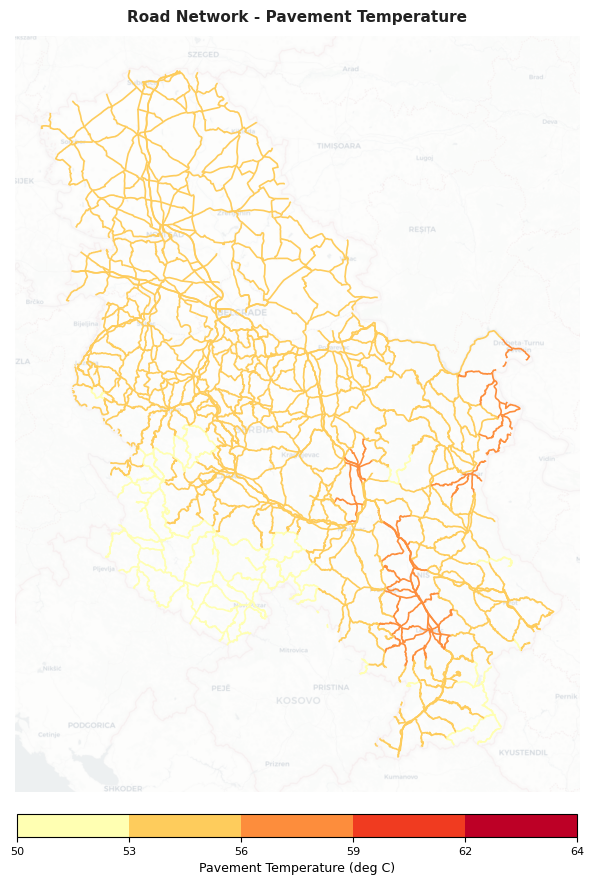

In [174]:
print("Current max pavement temperatures (without urban heat island effect)")
roads_current = assign_road_temperatures(roads, data, bounds, crs)
fig, ax = plot_road_temperatures(roads_current, "Road Network - Pavement Temperature")
plt.savefig(figure_path / "roads_current_max_pavement_temperatures.png", dpi=DPI, bbox_inches="tight")
plt.show()

### Future pavement temperatures with UHI on roads

Future max pavement temperatures considering climate change and urban heat islands
Roads with temperature assigned : 1,828
Roads outside raster extent     : 0
Temperature range on roads      : 50.42 - 63.91 deg C

Road segment distribution:
  Bin                Roads  % of total
  -------------------------------------
  50 - 53               35        1.9%
  53 - 56              233       12.7%
  56 - 59            1,080       59.1%
  59 - 62              248       13.6%
  62 - 64              232       12.7%
  -------------------------------------
  Total              1,828      100.0%


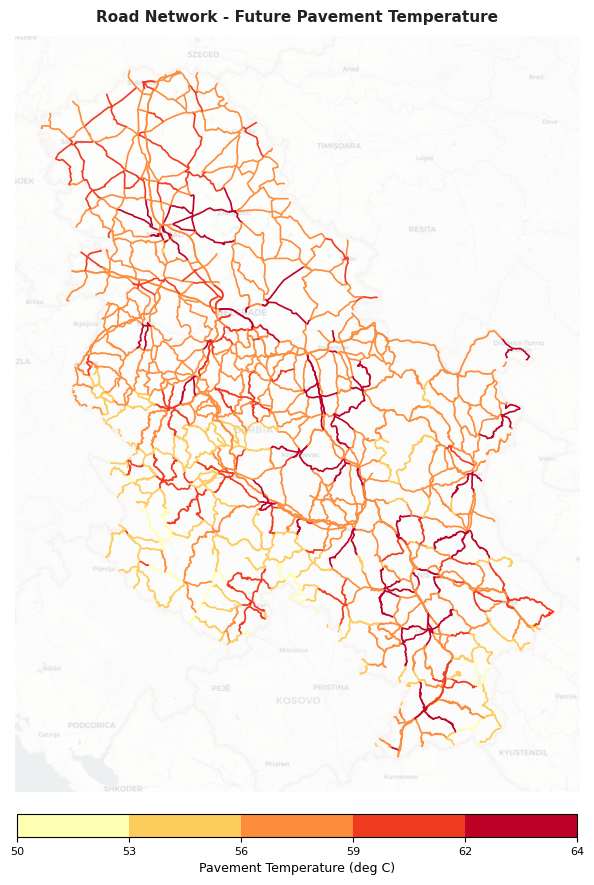

In [175]:
print("Future max pavement temperatures considering climate change and urban heat islands")
roads_future = assign_road_temperatures(roads, data_uhi, bounds, crs)
fig, ax = plot_road_temperatures(roads_future, "Road Network - Future Pavement Temperature")
plt.savefig(figure_path / "roads_future_max_pavement_temperatures.png", dpi=DPI, bbox_inches="tight")
plt.show()

## 5. Combined figure: Roads (A) + Raster (B)

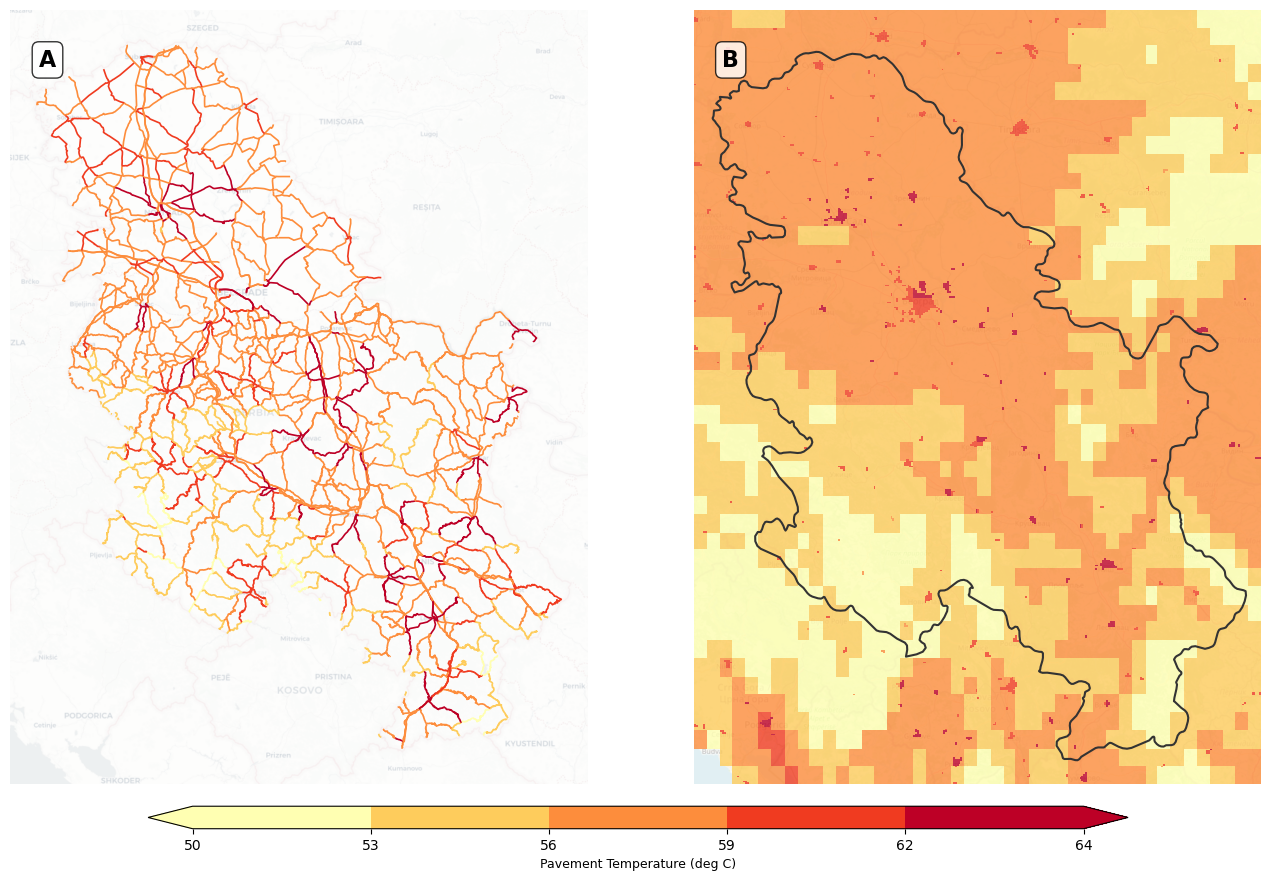

In [176]:
roads_plot = roads_future.to_crs(epsg=3857)

cmap = ListedColormap(ABS_COLORS_PAV)
norm = BoundaryNorm(ABS_BINS_PAV, cmap.N)

l, b, r, t = _reproject_bounds_to_3857(bounds, crs)

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(14, 9), facecolor="white")
fig.subplots_adjust(left=0.02, right=0.98, top=0.96, bottom=0.10, wspace=0.02)

# Panel A: Roads
roads_no_temp = roads_plot[roads_plot["max_temp"].isna()]
if len(roads_no_temp) > 0:
    roads_no_temp.plot(ax=ax_a, color="grey", linewidth=0.4, alpha=0.5, zorder=3)

roads_plot[roads_plot["max_temp"].notna()].plot(
    ax=ax_a, column="max_temp", cmap=cmap, norm=norm,
    linewidth=1.2, zorder=4,
)
cx.add_basemap(ax=ax_a, source=cx.providers.CartoDB.Positron, alpha=0.4, attribution=False)
ax_a.set_aspect("equal")
ax_a.margins(0)
ax_a.axis("off")
ax_a.text(0.05, 0.95, "A", transform=ax_a.transAxes, fontsize=16,
          fontweight="bold", verticalalignment="top",
          bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Panel B: Raster
ax_b.imshow(data_uhi, extent=[l, r, b, t], origin="upper",
            cmap=cmap, norm=norm, interpolation="nearest",
            alpha=0.80, zorder=3)
serbia_3857.plot(ax=ax_b, facecolor="none", edgecolor="#333333", linewidth=1.5, zorder=4)
cx.add_basemap(ax=ax_b, source=cx.providers.OpenStreetMap.Mapnik,
               alpha=0.35, attribution=False)
ax_b.set_aspect("equal")
ax_b.axis("off")
ax_b.text(0.05, 0.95, "B", transform=ax_b.transAxes, fontsize=16,
          fontweight="bold", verticalalignment="top",
          bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cax = fig.add_axes([0.15, 0.05, 0.70, 0.025])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal", extend="both")
cbar.set_label("Pavement Temperature (deg C)", fontsize=9)
cbar.set_ticks(ABS_BINS_PAV)

plt.savefig(figure_path / "pavement_temperature_AB.png", dpi=DPI, bbox_inches="tight")
plt.show()

## 6. Save ArcGIS layer for the future road temperatures

In [177]:
bin_labels = [f"{lo}-{hi} deg C" for lo, hi in zip(ABS_BINS_PAV[:-1], ABS_BINS_PAV[1:])]
roads_future["temp_class"] = pd.cut(
    roads_future["max_temp"],
    bins=ABS_BINS_PAV,
    labels=bin_labels,
    include_lowest=True,
).astype(str)
roads_future["temp_class"] = roads_future["temp_class"].where(
    roads_future["max_temp"].notna(), other="No data"
)

temp_labels = ["No data"] + bin_labels
temp_colors = ["#d3d3d3"] + ABS_COLORS_PAV
temp_widths = {label: 1.2 for label in temp_labels}

save_lyrx_layer(
    gdf=roads_future,
    gpkg_path=arcgis_gpkg / "heat_exposure_roads.gpkg",
    lyrx_path=arcgis_results / "heat_exposure_roads.lyrx",
    layer_name="heat_exposure_roads",
    labels=temp_labels,
    colors=temp_colors,
    width_mapping=temp_widths,
    field="temp_class",
    title="Future Pavement Temperature on Roads",
)

Saved GeoPackage -> C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2\results\ArcGIS layers\Geopackages\heat_exposure_roads.gpkg
Saved layer file -> C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2\results\ArcGIS layers\heat_exposure_roads.lyrx
